 о Библиотеке Дерево решений

  регрессия
  
  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

  классификация

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [ ]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [27]:
#Создание примера DataFrame
np.random.seed(42)  # для воспроизводимости
n_samples = 200
dohod = np.random.randint(30000, 100000, n_samples)  # Годовой доход (в долларах)
credit_his =  np.random.rand(n_samples)

# Преобразуем целевую переменную в бинарную (выдавать кредит или нет)
veroyatno_vydacha_credita  = 0.5 * dohod + 10000 * credit_his + np.random.normal(0, 5000, n_samples)
vydacha_credita  = (veroyatno_vydacha_credita > np.mean(veroyatno_vydacha_credita)).astype(int)  # 1 - выдавать, 0 - не выдавать
data = pd.DataFrame({'доход': dohod, 'кредитная_история': credit_his, 'выдача_кредита': vydacha_credita})
data

,доход,кредитная_история,выдача_кредита
0,45795,0.846661,0
1,30860,0.856324,0
2,84886,0.404508,1
3,36265,0.887770,0
4,67194,0.850928,1
...,...,...,...
195,91434,0.127690,1
196,73016,0.250016,1
197,37400,0.580544,0
198,72642,0.867117,1


# Чистое дерево

In [47]:
#  Подготовка данных
X = data[['доход', 'кредитная_история']]
y = data['выдача_кредита']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
y.value_counts() # смотрим распределение классов

,count
выдача_кредита,
0,100
1,100


In [48]:
#  Масштабирование признаков (не обязательно для деревьев, но для примера оставим)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
#  Обучение  дерева решений
tree = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=1, min_samples_split= 2, random_state=42)
tree.fit(X_train_scaled, y_train)

# Оценка модели
y_pred_tree_t = tree.predict(X_train_scaled)
y_pred_tree = tree.predict(X_test_scaled)

accuracy_tree_t = accuracy_score(y_train, y_pred_tree_t)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Дерево решений : Accuracy train = {accuracy_tree_t:.2f}")
print(f"Дерево решений : Accuracy test = {accuracy_tree:.2f}")
print("\nClassification Report :\n", classification_report(y_test, y_pred_tree))


Дерево решений : Accuracy train = 0.96
Дерево решений : Accuracy test = 0.82

Classification Report :
               precision    recall  f1-score   support

           0       0.89      0.77      0.83        22
           1       0.76      0.89      0.82        18

    accuracy                           0.82        40
   macro avg       0.83      0.83      0.82        40
weighted avg       0.83      0.82      0.83        40



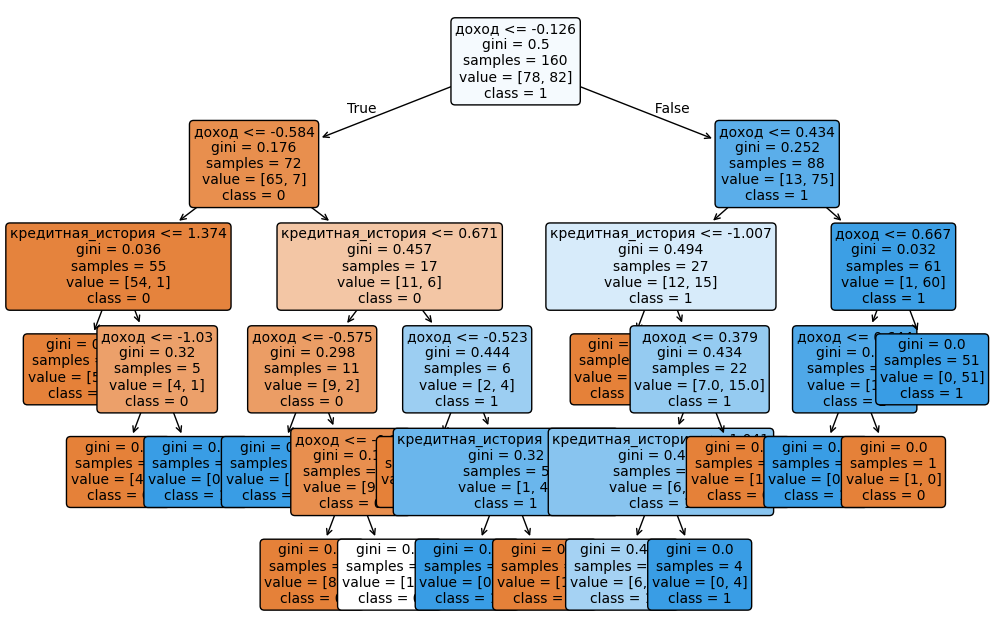

In [57]:
# 6. Визуализация дерева решений
plt.figure(figsize=(12, 8))  # Размер графика
plot_tree(tree,
          feature_names=X.columns,  # Названия признаков
          class_names=['0', '1'],     # Названия классов
          filled=True,              # Цветные узлы
          rounded=True,             # Закругленные углы
          fontsize=10)              # Размер шрифта
plt.show()  # Показываем график

In [40]:
# Предсказание для нового клиента
new_dohod = 60000
new_credit_his = 0.7

new_client = pd.DataFrame({'доход': [new_dohod], 'кредитная_история': [new_credit_his]})
new_client_scaled = scaler.transform(new_client)

veroyatno = tree.predict_proba(new_client_scaled)[0, 1]
vydacha = tree.predict(new_client_scaled)[0]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_dohod}, Кредитная история: {new_credit_his}")
print(f"Вероятность выдачи кредита: {veroyatno:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.00
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 0


# дерево с GridSearchCV

In [58]:
# Подготовка данных
X = data[['доход', 'кредитная_история']]
y = data['выдача_кредита']

# 3. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# Масштабирование признаков (для деревьев не обязательно, но может помочь в некоторых случаях)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
# Дерево решений для классификации
param_grid = {'max_depth': [2, 4, 6, 8],  # Ограничиваем максимальную глубину
              'min_samples_split': [2, 5, 10], # Минимальное количество образцов для разделения узла
              'min_samples_leaf': [1, 3, 5]}   # Минимальное количество образцов в листе

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42, criterion='gini'),  # Используем Gini impurity
                           param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train_scaled, y_train) # Обучаем на масштабированных данных (хотя это и не обязательно)

# Лучшая модель
best_tree = grid_search.best_estimator_
print("Лучшие параметры для дерева решений:", grid_search.best_params_)


Лучшие параметры для дерева решений: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [61]:
# Оценка модели
y_pred_tree_t =  best_tree.predict(X_train_scaled)
y_pred_tree = best_tree.predict(X_test_scaled)

accuracy_tree_t = accuracy_score(y_train, y_pred_tree_t)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Дерево решений : Accuracy train = {accuracy_tree_t:.2f}")
print(f"Дерево решений: Accuracy test = {accuracy_tree:.2f}")
print("\nClassification Report (Дерево решений):\n", classification_report(y_test, y_pred_tree))

Дерево решений : Accuracy train = 0.88
Дерево решений: Accuracy test = 0.80

Classification Report (Дерево решений):
               precision    recall  f1-score   support

           0       0.89      0.73      0.80        22
           1       0.73      0.89      0.80        18

    accuracy                           0.80        40
   macro avg       0.81      0.81      0.80        40
weighted avg       0.82      0.80      0.80        40



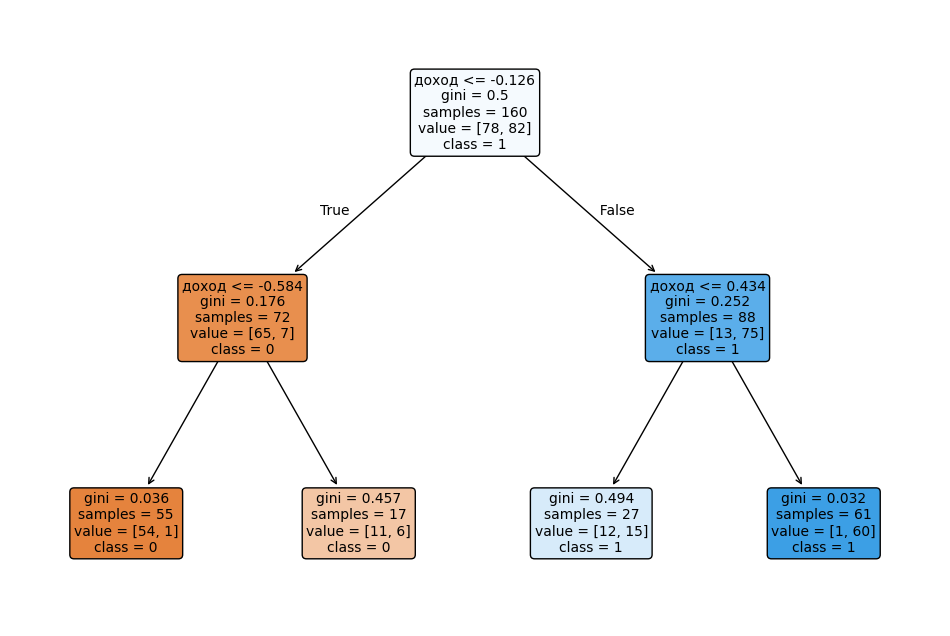

In [62]:
# 6. Визуализация дерева решений
plt.figure(figsize=(12, 8))  # Размер графика
plot_tree( best_tree,
          feature_names=X.columns,  # Названия признаков
          class_names=['0', '1'],     # Названия классов
          filled=True,              # Цветные узлы
          rounded=True,             # Закругленные углы
          fontsize=10)              # Размер шрифта
plt.show()  # Показываем график

In [45]:
# Предсказание для нового клиента
new_dohod = 60000
new_credit_his = 0.7

new_client = pd.DataFrame({'доход': [new_dohod], 'кредитная_история': [new_credit_his]})
new_client_scaled = scaler.transform(new_client)

veroyatno = best_tree.predict_proba(new_client_scaled)[0, 1]
vydacha = best_tree.predict(new_client_scaled)[0]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_dohod}, Кредитная история: {new_credit_his}")
print(f"Вероятность выдачи кредита: {veroyatno:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.35
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 0
